In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib
import matplotlib.cm as cm
from matplotlib.colors import Normalize


In [2]:
# constants
w1 = 20 # meV
w2 = 60 # meV
maxOmega = 300 # meV
m = 28 # amu
a = 0.543 # nm

In [3]:
def get_possible_n_j(omega, w1=20, w2=60): # meV
    maxN = int(omega/w1)
    pairs = [(n, j) for n in range(1,maxN + 1) for j in range(n + 1)]
    pairs_array = np.array(pairs)
    n_values = pairs_array[:, 0]
    j_values = pairs_array[:, 1]
    condition = (j_values * w1 + (n_values - j_values) * w2) <= omega
    filtered_pairs = pairs_array[condition]
    return filtered_pairs

def get_possible_omega(n_j_pairs, w1=20,w2=60):
    n_values = n_j_pairs[:, 0]
    j_values = n_j_pairs[:, 1]
    return j_values * w1 + (n_values - j_values) * w2

In [4]:
def remove_degeneracy(omega_list, s_list):
    unique_omega = np.unique(omega_list)
    unique_s = []
    for val in unique_omega:
        indices = np.where(omega_list == val)[0]
        unique_s.append(np.sum(s_list[indices], axis=0))
    return unique_omega, np.array(unique_s)

In [5]:
# up to a constant factor
def get_diag(n,j,q, m=28, w1=20, w2=60): 
    '''
    n: total number of phonons
    j: number of omega+ phonons
    q: keV
    a: keV^-1
    m: amu
    w1, w2: meV
    '''
    # unit conversion
    m = m*9.31*1e5 # from amu to keV
    w1 = w1*1e-6 # from meV to keV
    w2 = w2*1e-6 # from meV to keV
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return np.exp(-2*debye_waller) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

def get_off_diag(n,j,q, a=0.543, m=28, w1=20, w2=60): 
    '''
    n: total number of phonons
    j: number of omega+ phonons
    q: keV
    a: nm
    m: amu
    w1, w2: meV
    '''
    # unit conversion
    a = a * 5.064225 # from nm to keV^-1
    m = m*9.31*1e5 # from amu to keV
    w1 = w1*1e-6 # from meV to keV
    w2 = w2*1e-6 # from meV to keV
    debye_waller = q**2 / (8*m) * (1/w1 +1/w2)
    return (-1**(n-j)) * np.exp(-2*debye_waller) * np.cos(q*a) * (q**2/(4*m))**n / (math.factorial(j) * math.factorial(n-j) * (w1**j) * (w2**(n-j)))

In [6]:
n_j_list = get_possible_n_j(maxOmega)
possible_omega_list = get_possible_omega(n_j_list)
qbz = 2*np.pi / (a * 5.064225) # keV
log_q_list = np.linspace(0, np.log10(400), 5000)
q_list = 10**log_q_list # keV

s_list = []
s_diag_list = []
for n_j_pairs in n_j_list:
    s_list.append(get_diag(n_j_pairs[0],n_j_pairs[1],q_list)+get_off_diag(n_j_pairs[0],n_j_pairs[1],q_list))
    s_diag_list.append(get_diag(n_j_pairs[0],n_j_pairs[1],q_list))
clean_omega_list, clean_s_list = remove_degeneracy(possible_omega_list, np.array(s_list))
clean_omega_list, clean_s_diag_list = remove_degeneracy(possible_omega_list, np.array(s_diag_list))

In [7]:
omega_list = np.linspace(0, maxOmega, 4000) # meV
s_list_plot = np.zeros((len(omega_list), len(log_q_list)))
s_diag_list_plot = np.zeros((len(omega_list), len(log_q_list)))

for i, w in enumerate(clean_omega_list):
    ind = np.where((omega_list > w - 0.6) & (omega_list < w + 0.6))[0]
    s_list_plot[ind, :] = clean_s_list[i]
    s_diag_list_plot[ind, :] = clean_s_diag_list[i]

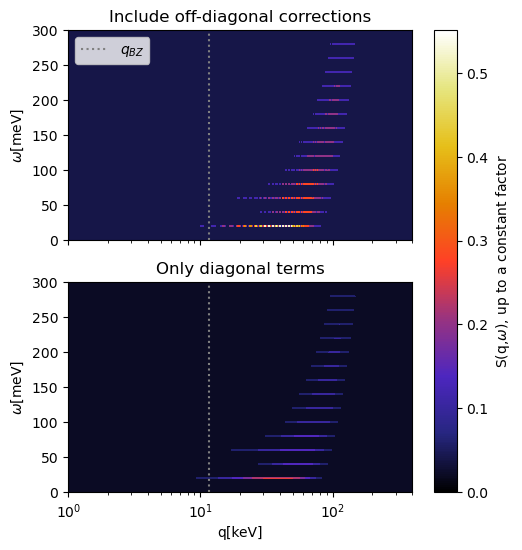

In [8]:
X, Y = np.meshgrid(q_list,omega_list)
fig, axes = plt.subplots(nrows=2, figsize=(4,6),sharey=True,sharex=True)
cmap = matplotlib.colormaps.get_cmap('CMRmap')
normalizer = Normalize(0, np.max(s_list_plot))
im = cm.ScalarMappable(norm=normalizer, cmap='CMRmap')


axes[0].contourf(X, Y, s_list_plot,cmap='CMRmap',norm=normalizer)
axes[0].axvline(2*np.pi/a, linestyle=':', color='gray',label=r'$q_{BZ}$')
axes[0].set_xscale('log')
axes[0].set_title('Include off-diagonal corrections')
axes[0].set_ylabel('$\omega$[meV]')
axes[0].legend(loc='upper left')


axes[1].contourf(X, Y, s_diag_list_plot,cmap='CMRmap', norm=normalizer)
axes[1].axvline(2*np.pi/a, linestyle=':', color='gray')
axes[1].set_xscale('log')
axes[1].set_title('Only diagonal terms')
axes[1].set_xlabel('q[keV]')
axes[1].set_ylabel('$\omega$[meV]')

fig.subplots_adjust(right=1.2, wspace=0)
cbar = fig.colorbar(im, ax=axes.ravel().tolist())
cbar.set_label(r'S(q,$\omega$), up to a constant factor', )

plt.savefig('structure_factor_2d', dpi=300,bbox_inches="tight")
plt.show()
# plt.tight_layout()

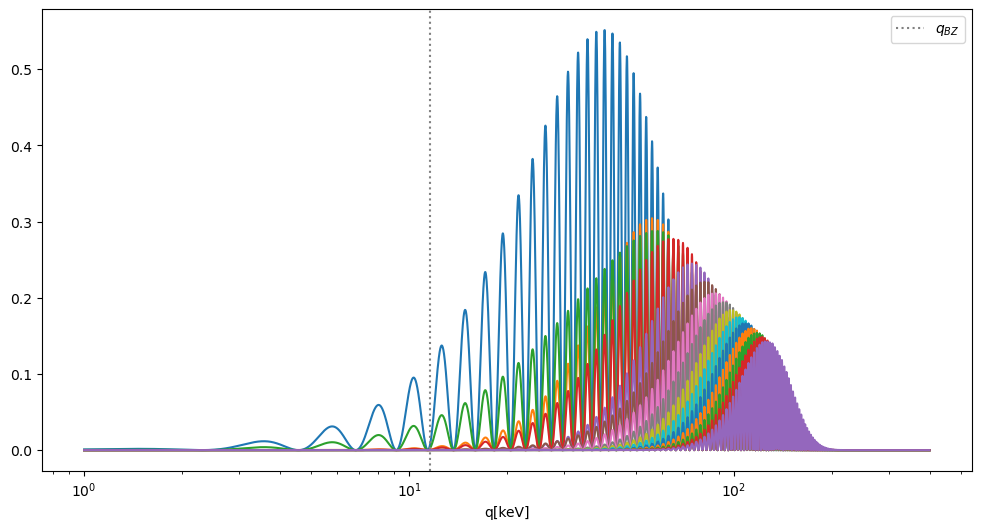

In [9]:
plt.figure(figsize=(12, 6))
for item in clean_s_list:
    plt.plot(q_list,item)

# plt.plot(q_list,s_diag_list[4])
plt.axvline(2*np.pi/a,linestyle=':',color='gray', label=r'$q_{BZ}$')
# plt.xlim(0,4*np.pi/a)
# plt.ylim(0,3*1e-5)
plt.xscale('log')
plt.xlabel('q[keV]')
plt.legend()
plt.show()

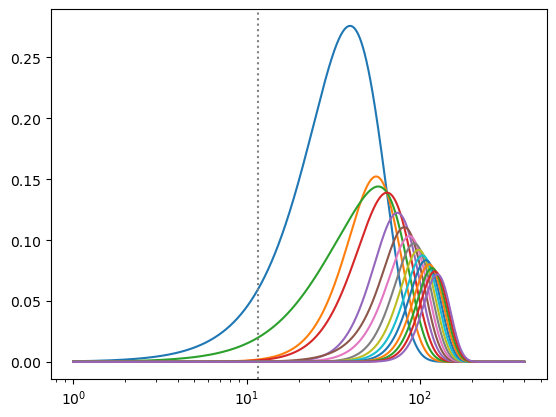

In [10]:
for item in clean_s_diag_list:
    plt.plot(q_list,item)

# plt.plot(q_list,s_diag_list[4])
plt.axvline(2*np.pi/a,linestyle=':',color='gray')
# plt.xlim(0,4*np.pi/a)
# plt.ylim(0,3*1e-5)
plt.xscale('log')

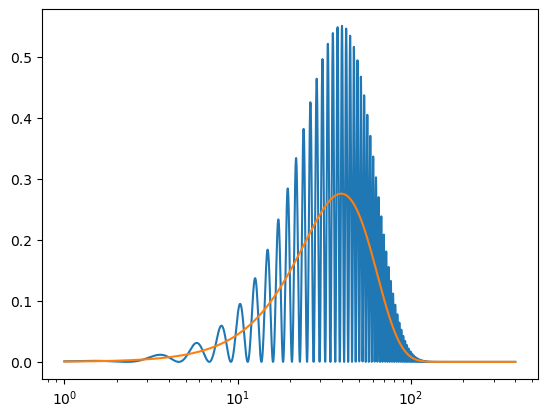

In [11]:
plt.plot(q_list, clean_s_list[0])
plt.plot(q_list, clean_s_diag_list[0])
plt.xscale('log')